# Finančne delnice – analiza tveganja in donosnosti

V projektu analiziramo 50 družb iz finančnega sektorja. Za vsako družbo imamo temeljne finančne kazalnike ter približno 150 trgovalnih dni zgodovinskih cen delnic.

Glavni cilj analize je preučiti razmerje med donosnostjo in tveganjem ter preveriti povezave med temeljnimi finančnimi kazalniki in tržnim obnašanjem delnic.

V analizi bomo med drugim preverili:
- katere delnice so v opazovanem obdobju dosegle najvišjo donosnost,
- katere delnice so bile najbolj volatilne,
- katere družbe so imele najboljše razmerje med donosnostjo in tveganjem,
- kako močno so donosi posameznih delnic med seboj povezani,
- ali obstaja povezava med kazalniki, kot so ROE, P/B, beta in tržno obnašanje delnicc.



## 1. Pregled in priprava podatkov

Najpre pregledamo zbrane podatke, preverimo njihovo strukturo, manjkajoče vrednosti in podatkovne tipe ter jih pripravimo za nadaljnjo finančno analizo.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

companies = pd.read_csv("companies.csv")
prices = pd.read_csv("prices.csv")

print("Companies:", companies.shape)
print("Prices:", prices.shape)


Companies: (50, 36)
Prices: (6300, 9)


In [57]:
companies.head()

,ticker,company_name,link,market_cap_B,change,volume,revenue_B,pe_ratio,forward_pe,pb_ratio,...,dividend_yield,dividend_growth,payout_ratio,buyback_yield,shareholder_yield,price_target_difference,analyst_consensus,analyst_count,revenue_growth_forecast_3y,eps_growth_forecast_3y
0,BRK.B,Berkshire Hathaway Inc.,https://stockanalysis.com/stocks/brk.b/,1080.00,-0.0057,3969452,384.69,12.55,22.88,1.43,...,NaN,NaN,NaN,0.0000,0.0000,0.0847,Buy,4.0,0.0558,0.0395
1,JPM,JPMorgan Chase & Co.,https://stockanalysis.com/stocks/jpm/,964.50,-0.0007,5057884,186.33,15.59,15.05,2.73,...,0.0167,0.1321,0.2575,0.0357,0.0522,0.0420,Buy,24.0,0.0649,0.1073
2,V,Visa Inc.,https://stockanalysis.com/stocks/v/,668.44,-0.0036,8106908,44.49,31.01,25.19,19.30,...,0.0073,0.1356,0.2281,0.0288,0.0361,0.1400,Strong Buy,40.0,0.1191,0.1399
3,MA,Mastercard Incorporated,https://stockanalysis.com/stocks/ma/,498.70,0.0040,2473346,35.08,31.58,27.01,89.79,...,0.0061,0.1463,0.1914,0.0235,0.0295,0.1614,Strong Buy,40.0,0.1276,0.1629
4,BAC,Bank of America Corporation,https://stockanalysis.com/stocks/bac/,450.96,0.0062,21845904,113.93,14.84,12.91,1.63,...,0.0200,0.0943,0.2957,0.0372,0.0572,0.0724,Buy,24.0,0.0598,0.1578


In [58]:
prices.head()

,ticker,date,open,high,low,close,adj_close,change,volume
0,BRK.B,"Aug 21, 2026",498.50,501.00,495.68,495.82,495.82,-0.0021,4598255
1,BRK.B,"Aug 20, 2026",499.65,500.44,496.48,496.86,496.86,-0.0055,3267221
2,BRK.B,"Aug 19, 2026",503.41,507.07,499.41,499.62,499.62,-0.0066,3507845
3,BRK.B,"Aug 18, 2026",501.04,504.50,499.60,502.96,502.96,0.0095,3341550
4,BRK.B,"Aug 17, 2026",504.45,505.31,498.07,498.23,498.23,-0.0115,4726975


### Manjkajoče vrednosti in podvojeni zapisi

Pred nadaljnjo analizo preverimo, ali podatki vsebujejo manjkajoče vrednosti 
ali podvojene zapise. To je pomembno, saj lahko takšne nepravilnosti vplivajo 
na izračun donosnosti, tveganja in drugih statističnih kazalnikov.

In [59]:
companies.isna().sum()

ticker                         0
company_name                   0
link                           0
market_cap_B                   0
change                         0
volume                         0
revenue_B                      0
pe_ratio                       0
forward_pe                     1
pb_ratio                       0
peg_ratio                     24
earnings_yield                 0
roe                            0
roa                            0
operating_margin               0
profit_margin                  0
eps                            0
beta                           0
price_change_52w               0
rsi                            0
short_percent_float            8
short_ratio                    3
cash_B                         0
total_debt_B                   0
equity_B                       0
book_value_per_share           0
dividend_yield                 2
dividend_growth                2
payout_ratio                   2
buyback_yield                  0
shareholde

Pri nekaterih finančnih kazalnikih manjkajo posamezne vrednosti. 
Največ manjkajočih podatkov je pri kazalniku PEG Ratio. Ker se razpoložljivost 
podatkov med kazalniki razlikuje, družb ne bomo odstranili iz celotne analize, 
temveč bomo manjkajoče vrednosti obravnavali ločeno pri posameznih analizah.

In [60]:
prices.isna().sum()

ticker        0
date          0
open          0
high          0
low           0
close         0
adj_close     0
change       35
volume        0
dtype: int64

Pri zgodovinskih podatkih manjkajo posamezne vrednosti samo v stolpcu change. 
Ker bomo dnevne donosnosti izračunali neposredno iz cen delnic, te manjkajoče 
vrednosti ne vplivajo na nadaljnjo analizo.


Preverimo tudi morebitne podvojene zapise. V tabeli companies mora biti 
vsaka družba zapisana samo enkrat, v tabeli prices pa mora biti enolična 
kombinacija oznake delnice in datuma.

In [61]:
prices.duplicated(subset=["ticker", "date"]).sum()

np.int64(0)

In [62]:
companies["ticker"].duplicated().sum()

np.int64(0)

Podvojenih družb ali dnevnih cenovnih zapisov v podatkih ni.


In [63]:
prices["date"] = pd.to_datetime(prices["date"])

prices = prices.sort_values(["ticker", "date"])
prices = prices.reset_index(drop = True)

## 2. Analiza donosnosti

Za primerjavo uspešnosti delnic ne primerjamo neposredno njihovih cen, saj imajo
različne delnice zelo različne ravni cen. Namesto tega izračunamo dnevne
donosnosti, ki merijo relativno spremembo cene med dvema zaporednima
trgovalnima dnevoma.


Dnevno donosnost izračunamo na podlagi zaključnih cen. Prvo opazovanje za vsako družbo nima izračunane donosnosti, saj v podatkih nimamo predhodne trgovalne cene.

In [64]:
prices["return"] = prices.groupby("ticker")["close"].pct_change()

In [65]:
prices[["ticker", "date", "close", "return"]].head(6)

,ticker,date,close,return
0,AON,2026-02-23,315.31,NaN
1,AON,2026-02-24,319.33,0.012749
2,AON,2026-02-25,324.66,0.016691
3,AON,2026-02-26,330.27,0.017280
4,AON,2026-02-27,335.47,0.015745
5,AON,2026-03-02,337.80,0.006945


### Donosnost v opazovanem obdobju

Poleg dnevnih donosnosti izračunamo tudi skupno donosnost posamezne delnice
v celotnem opazovanem obdobju. Pri tem primerjamo prilagojeno zaključno ceno
na začetku in na koncu obdobja.

In [ ]:
period_returns = prices.groupby("ticker")["adj_close"].agg(
    first_price="first",
    last_price="last")

period_returns["period_return"] = (
    period_returns["last_price"] / period_returns["first_price"] - 1)

In [67]:
top_returns = period_returns.sort_values("period_return", ascending= False).head(10)

top_returns_display = top_returns.copy()

top_returns_display["period_return"] = (
    top_returns_display["period_return"] * 100).round(2)

top_returns_display

,first_price,last_price,period_return
ticker,,,
HOOD,71.78,108.13,50.64
BNY,114.63,158.49,38.26
UBS,41.00,53.29,29.98
MS,165.00,214.20,29.82
BX,111.53,143.38,28.56
BBVA,23.11,29.04,25.66
TD,93.81,117.15,24.88
BMO,140.17,174.43,24.44
HSBC,84.15,104.15,23.77


Za primerjavo pogledamo tudi deset delnic z najnižjo skupno donosnostjo
v opazovanem obdobju.

In [68]:
bottom_returns = period_returns.sort_values("period_return", ascending=True).head(10)

bottom_returns_display = bottom_returns.copy()

bottom_returns_display["period_return"] = (
    bottom_returns_display["period_return"] * 100).round(2)

bottom_returns_display

,first_price,last_price,period_return
ticker,,,
HDB,32.22,23.60,-26.75
ITUB,9.03,7.48,-17.17
CME,305.09,274.98,-9.87
BN,43.85,41.69,-4.93
IBN,30.38,29.91,-1.55
WFC,84.18,83.84,-0.40
BRK.B,494.09,495.82,0.35
CB,331.37,340.99,2.90
AXP,319.35,336.00,5.21


Za preglednejšo primerjavo deset delnic z najvišjo donosnostjo rezultate
prikažemo še grafično.

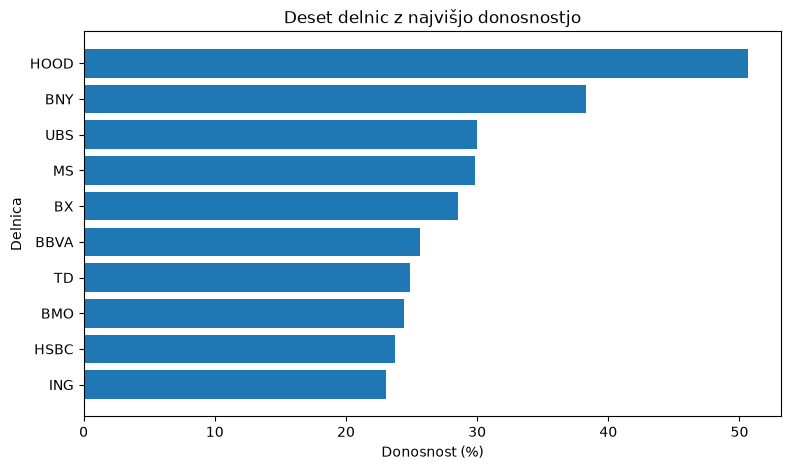

In [ ]:
plt.figure(figsize=(9, 5))

plt.barh(
    top_returns.index,
    top_returns["period_return"] * 100
)
plt.title("Deset delnic z najvišjo donosnostjo")
plt.xlabel("Donosnost (%)")
plt.ylabel("Delnica")
plt.gca().invert_yaxis()

plt.show()

## 3. Analiza tveganja

Donosnost sama po sebi ne pove, koliko tvegana je bila posamezna naložba.
Zato poleg donosnosti analiziramo tudi nihanje dnevnih donosnosti delnic.
Kot osnovno mero tveganja uporabimo volatilnost, ki temelji na standardnem
odklonu dnevnih donosnosti.

In [70]:
daily_volatility = prices.groupby("ticker")["return"].std()

annual_volatility = daily_volatility * np.sqrt(252)

period_returns["annual_volatility"] = annual_volatility

Dnevno volatilnost pretvorimo na letno raven z uporabo približno 252
trgovalnih dni na leto. Tako lahko tveganje posameznih delnic izrazimo
v bolj običajni letni obliki.

### Letna donosnost

Ker opazovano obdobje obsega približno polovico trgovalnega leta, skupno
donosnost pretvorimo tudi na letno raven. Pri tem upoštevamo obrestno-obrestni
učinek in približno 252 trgovalnih dni v letu.

In [71]:
return_counts = prices.groupby("ticker")["return"].count()

period_returns["annual_return"] = (
    (1 + period_returns["period_return"]) ** (252 / return_counts)- 1)

### Razmerje med donosnostjo in tveganjem

Za vsako delnico primerjamo letno preračunano donosnost in letno volatilnost.
Vsaka točka predstavlja eno družbo. Višji položaj na grafikonu pomeni višjo
donosnost, premik v desno pa večjo volatilnost oziroma tveganje.

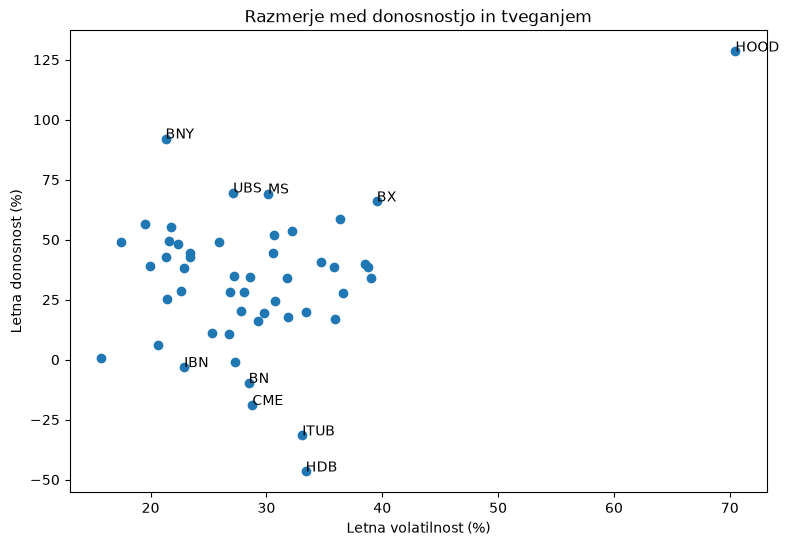

In [72]:
top_5 = period_returns.nlargest(5, "annual_return")
bottom_5 = period_returns.nsmallest(5, "annual_return")

labeled_companies = pd.concat([top_5, bottom_5])

plt.figure(figsize=(9, 6))
plt.scatter(
    period_returns["annual_volatility"] * 100,
    period_returns["annual_return"] * 100)

for ticker, row in labeled_companies.iterrows():
    plt.annotate(ticker,
        (row["annual_volatility"] * 100,
        row["annual_return"] * 100))

plt.xlabel("Letna volatilnost (%)")
plt.ylabel("Letna donosnost (%)")
plt.title("Razmerje med donosnostjo in tveganjem")

plt.show()


Graf prikazuje razmerje med letno preračunano donosnostjo in letno
volatilnostjo analiziranih delnic. Višji položaj pomeni višjo donosnost,
premik v desno pa večjo volatilnost oziroma tveganje.

Zaradi boljše preglednosti so označene le družbe s petimi najvišjimi in
petimi najnižjimi letnimi donosnostmi. Tako lahko opazimo, da višja
donosnost ni nujno povezana z nižjim tveganjem, zato je pri primerjavi
delnic smiselno upoštevati oba kazalnika hkratti.

### Sharpejevo razmerje

Sama donosnost ne upošteva tveganja, ki ga je bilo treba prevzeti za njeno
doseganje. Zato izračunamo tudi Sharpejevo razmerje, ki primerja donosnost
z volatilnostjo delnice.

Pri izračunu zaradi poenostavitve predpostavimo netvegano obrestno mero
enako nič. Višje Sharpejevo razmerje pomeni ugodnejše razmerje med
donosnostjo in tveganjem.

In [73]:
mean_daily_return = prices.groupby("ticker")["return"].mean()

annual_mean_return = mean_daily_return * 252

period_returns["sharpe_ratio"] = (annual_mean_return / period_returns["annual_volatility"])

Naslednja tabela prikazuje deset delnic z najvišjim Sharpejevim razmerjem,
torej delnice z najugodnejšim razmerjem med povprečno donosnostjo in
volatilnostjo v opazovanem obdobju.

In [74]:
top_sharpe = period_returns.nlargest(10, "sharpe_ratio")

top_sharpe

,first_price,last_price,period_return,annual_volatility,annual_return,sharpe_ratio
ticker,,,,,,
BNY,114.63,158.49,0.382622,0.212893,0.921580,3.102050
RY,168.42,205.23,0.218561,0.174071,0.489594,2.228955
TD,93.81,117.15,0.248801,0.194761,0.565057,2.178792
BMO,140.17,174.43,0.244417,0.217447,0.554002,1.997737
UBS,41.00,53.29,0.299756,0.271272,0.696467,1.988438
BAC,50.52,61.69,0.221101,0.216098,0.495860,1.871324
V,305.32,371.04,0.215250,0.223735,0.481445,1.831945
MS,165.00,214.20,0.298182,0.301389,0.692328,1.824591
JPM,294.83,351.58,0.192484,0.213311,0.426029,1.679834


### Value at Risk in Conditional Value at Risk

Za dodatno oceno tveganja uporabimo zgodovinski Value at Risk (VaR) in
Conditional Value at Risk (CVaR) pri 95-odstotni ravni zaupanja.

VaR ocenjuje mejo dnevne izgube, ki je bila v opazovanem obdobju presežena
približno v 5 % trgovalnih dni. CVaR pa meri povprečno izgubo v teh
najslabših 5 % dnevnih donosnosti.

Naslednja tabela prikazuje deset delnic z največjim CVaR. Višja vrednost
pomeni večjo povprečno izgubo v najneugodnejših dnevih opazovanega obdobja.
Za primerjavo sta prikazana tudi VaR in letna volatilnost.

In [75]:
daily_var_95 = (prices.groupby("ticker")["return"].quantile(0.05))
period_returns["var_95"] = -daily_var_95

def calculate_cvar(returns):
    var_limit = returns.quantile(0.05)
    worst_returns = returns[returns <= var_limit]
    return -worst_returns.mean()

period_returns["cvar_95"] = (prices.groupby("ticker")["return"].apply(calculate_cvar))

highest_tail_risk = period_returns.nlargest(10, "cvar_95")

highest_tail_risk[["var_95", "cvar_95", "annual_volatility"]]


,var_95,cvar_95,annual_volatility
ticker,,,
HOOD,0.058386,0.075332,0.704841
HDB,0.032274,0.050751,0.333901
APO,0.033865,0.050511,0.387500
GS,0.035278,0.049639,0.358709
SAN,0.037522,0.046912,0.390190
BX,0.038054,0.046538,0.395278
MFG,0.036830,0.045077,0.365929
KKR,0.036858,0.044570,0.385119
BBVA,0.032236,0.043318,0.363124


## 4. Korelacijska analiza in diverzifikacija

Pri oblikovanju portfelja ni pomembno samo tveganje posamezne delnice,
temveč tudi način, kako se donosnosti različnih delnic gibljejo med seboj.
Korelacija meri povezanost gibanja donosnosti dveh delnic in je zato
pomembna pri ocenjevanju možnosti diverzifikacije.

In [76]:
returns_wide = prices.pivot(
    index="date",
    columns="ticker",
    values="return"
)
returns_wide.head()

ticker,AON,APO,AXP,BAC,BAM,BBVA,BCS,BLK,BMO,BN,...,SAN,SCHW,SMFG,SPGI,TD,TRV,UBS,USB,V,WFC
date,,,,,,,,,,,,,,,,,,,,,
2026-02-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-02-24,0.012749,0.003517,-0.002366,-0.012923,0.011269,-0.006754,0.001195,0.009374,0.000070,0.022500,...,-0.017282,0.003989,-0.021212,0.033327,-0.007618,0.000131,-0.007946,-0.013976,0.002284,-0.006812
2026-02-25,0.016691,0.026987,0.020625,0.025392,0.021048,0.010200,0.019491,0.011776,0.040970,0.013336,...,0.055955,0.023948,-0.005750,0.012767,0.021979,-0.002194,0.008252,0.018535,0.018781,0.025896
2026-02-26,0.017280,-0.023974,0.025161,0.011801,-0.015158,-0.004628,-0.013266,-0.003209,0.004861,-0.003071,...,-0.020439,0.022758,0.016014,0.032766,0.016464,0.004856,0.008666,0.021588,0.011853,-0.005302
2026-02-27,0.015745,-0.085664,-0.078790,-0.047228,-0.040632,-0.022401,-0.039937,-0.024801,-0.033053,-0.035424,...,-0.044822,-0.023790,-0.017513,0.010035,-0.014375,0.007837,-0.011217,-0.045407,0.010862,-0.056199


In [77]:
correlation_matrix = returns_wide.corr()

Za preglednejšo analizo izberemo 10 družb z največjo tržno kapitalizacijo
in prikažemo korelacije njihovih dnevnih donosnosti. S tem se izognemo
nepregledni matriki vseh 50 družb.

In [78]:
largest_tickers = companies.nlargest(10,"market_cap_B")["ticker"]

correlation_top10 = correlation_matrix.loc[largest_tickers,
                    largest_tickers]
correlation_top10.round(2)

ticker,BRK.B,JPM,V,MA,BAC,HSBC,MS,GS,RY,WFC
ticker,,,,,,,,,,
BRK.B,1.00,0.17,0.29,0.35,0.13,0.11,-0.09,-0.11,0.01,0.09
JPM,0.17,1.00,0.15,0.13,0.78,0.51,0.65,0.65,0.60,0.72
V,0.29,0.15,1.00,0.84,0.22,0.03,-0.04,-0.08,-0.01,0.17
MA,0.35,0.13,0.84,1.00,0.21,0.02,-0.03,-0.06,0.04,0.16
BAC,0.13,0.78,0.22,0.21,1.00,0.46,0.68,0.57,0.64,0.78
HSBC,0.11,0.51,0.03,0.02,0.46,1.00,0.56,0.56,0.56,0.34
MS,-0.09,0.65,-0.04,-0.03,0.68,0.56,1.00,0.86,0.58,0.49
GS,-0.11,0.65,-0.08,-0.06,0.57,0.56,0.86,1.00,0.59,0.41
RY,0.01,0.60,-0.01,0.04,0.64,0.56,0.58,0.59,1.00,0.54


Za lažjo vizualno primerjavo korelacijsko matriko prikažemo še grafično.
Višja pozitivna korelacija pomeni bolj podobno gibanje dnevnih donosnosti,
nižja korelacija pa lahko pomeni večji potencial za diverzifikacijo.

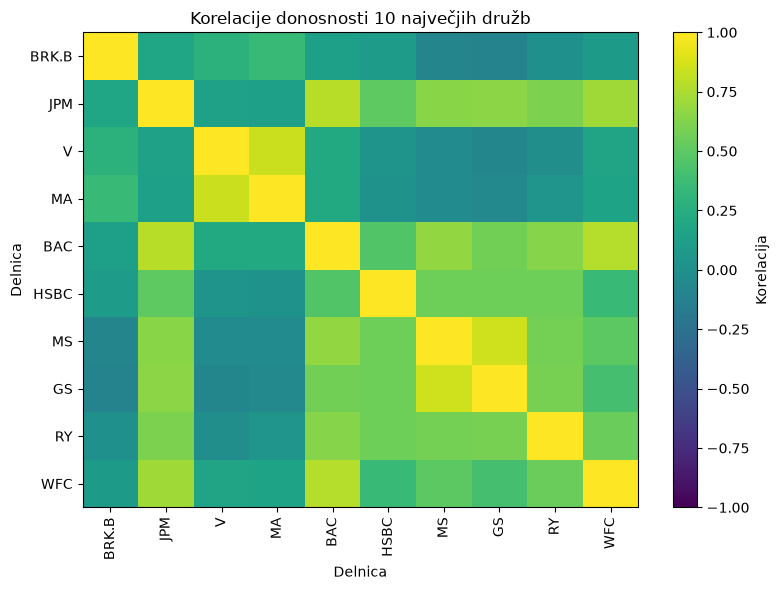

In [ ]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_top10,
    aspect="auto",
    vmin=-1,
    vmax=1)
plt.colorbar(label="Korelacija")
plt.xticks(
    range(len(correlation_top10.columns)),
    correlation_top10.columns,
    rotation=90)
plt.yticks(
    range(len(correlation_top10.index)),
    correlation_top10.index)

plt.title("Korelacije donosnosti 10 največjih družb")
plt.ylabel("Delnica")
plt.xlabel("Delnica")

plt.tight_layout()
plt.show()

### Najvišje in najnižje korelacije

Za podrobnejšo analizo poiščemo pare delnic z najvišjo in najnižjo
korelacijo dnevnih donosnosti. Nižja medsebojna korelacija lahko pomeni
večji potencial za diverzifikacijo, saj se donosnosti takšnih delnic
gibljejo manj podobno.

In [80]:
correlation_pairs = (
    correlation_matrix
    .rename_axis(index="ticker_1", columns="ticker_2")
    .stack()
    .rename("correlation")
    .reset_index()
)
correlation_pairs.columns = [
    "ticker_1",
    "ticker_2",
    "correlation"
]
correlation_pairs = correlation_pairs[
    correlation_pairs["ticker_1"] < correlation_pairs["ticker_2"]]

highest_correlations = correlation_pairs.nlargest(10,"correlation")
lowest_correlations = correlation_pairs.nsmallest(10,"correlation")

Naslednji dve tabeli prikazujeta deset parov delnic z najvišjo in deset parov delnic z najnižjo korelacijo dnevnih donosnosti.

In [81]:
highest_correlations.round(3)

,ticker_1,ticker_2,correlation
1792,MUFG,SMFG,0.916
329,BCS,LYG,0.908
1947,PNC,USB,0.903
1642,MFG,SMFG,0.901
1486,LYG,NWG,0.900
1593,MCO,SPGI,0.878
544,BNS,TD,0.875
290,BBVA,SAN,0.873
1279,ING,LYG,0.870
444,BMO,TD,0.864


In [82]:
lowest_correlations.round(3)

,ticker_1,ticker_2,correlation
987,GS,PGR,-0.354
769,CB,GS,-0.354
337,BCS,PGR,-0.326
1837,NWG,PGR,-0.317
983,GS,MRSH,-0.308
333,BCS,MRSH,-0.300
890,CME,SAN,-0.296
587,BNY,PGR,-0.294
1889,PGR,RY,-0.290
1287,ING,PGR,-0.288


## 5. Povezava med temeljnimi kazalniki in tržnim obnašanjem

Poleg analize donosnosti in tveganja preverimo tudi, ali so nekateri
temeljni in tržni kazalniki povezani z dejanskim obnašanjem delnic
v opazovanem obdobju.

### Beta in realizirana volatilnost

Beta meri občutljivost delnice na gibanje širšega trga, medtem ko
realizirana volatilnost meri dejansko nihanje dnevnih donosnosti v
opazovanem obdobju. Preverimo, ali imajo delnice z višjo beto tudi
višjo realizirano volatilnost.

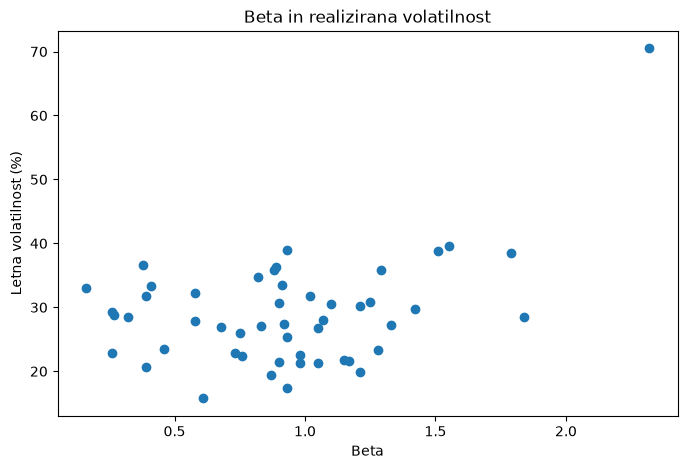

In [83]:
analysis_data = companies.set_index("ticker").join(
    period_returns[["annual_volatility", "annual_return", "sharpe_ratio"]])

beta_volatility_corr = analysis_data[
    ["beta", "annual_volatility"]].corr().iloc[0, 1]



plt.figure(figsize=(8, 5))
plt.scatter(
    analysis_data["beta"],
    analysis_data["annual_volatility"] * 100)

plt.xlabel("Beta")
plt.ylabel("Letna volatilnost (%)")
plt.title("Beta in realizirana volatilnost")

plt.show()

### Donosnost kapitala in razmerje P/B

Preverimo tudi povezavo med donosnostjo lastniškega kapitala (ROE) in
razmerjem med tržno in knjigovodsko vrednostjo podjetja (P/B).
Višji ROE pomeni večjo donosnost lastniškega kapitala, medtem ko višje
razmerje P/B pomeni, da trg podjetje vrednoti višje glede na njegovo
knjigovodsko vrednost.

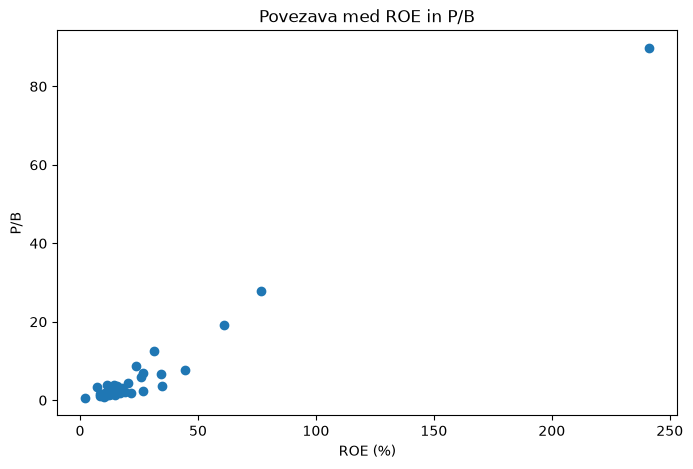

In [84]:
roe_pb_corr = companies[["roe", "pb_ratio"]].corr().iloc[0, 1]

plt.figure(figsize=(8, 5))

plt.scatter(
    companies["roe"] * 100,
    companies["pb_ratio"]
)

plt.xlabel("ROE (%)")
plt.ylabel("P/B")
plt.title("Povezava med ROE in P/B")

plt.show()

## 6. Sklep

V projektu smo analizirali 50 večjih družb iz finančnega sektorja na podlagi
temeljnih kazalnikov ter približno šestih mesecev dnevnih podatkov o cenah
delnic. Glavni namen analize je bil primerjati donosnost in tveganje posameznih
delnic ter preveriti, kako se njihovi donosi gibljejo med seboj.

Rezultati kažejo, da visoka donosnost sama po sebi še ne pomeni ugodne
naložbe z vidika tveganja. Delnica HOOD je v opazovanem obdobju dosegla
najvišjo skupno donosnost, približno 50,6 %, vendar je imela hkrati tudi
izrazito visoko volatilnost in največji CVaR med analiziranimi družbami.
To kaže, da je bila visoka donosnost povezana tudi z bistveno večjim tveganjem.

Drugačno sliko dobimo pri uporabi Sharpejevega razmerja, ki donosnost primerja
z volatilnostjo. Najvišje Sharpejevo razmerje je dosegla delnica BNY, čeprav
ni imela najvišje skupne donosnosti. To potrjuje, da razvrstitev delnic samo
glede na doseženo donosnost ne daje popolne slike njihove uspešnosti.

Med analiziranimi družbami so bile opazne tudi velike razlike v uspešnosti.
Medtem ko so nekatere delnice v opazovanem obdobju dosegle visoke pozitivne
donosnosti, je na primer HDB izgubila približno 26,8 % vrednosti.

Korelacijska analiza je pokazala, da se tudi delnice znotraj istega sektorja
ne gibljejo popolnoma enako. Nekateri pari, kot sta V in MA oziroma MS in GS,
so imeli visoko pozitivno korelacijo, medtem ko je bila pri nekaterih drugih
parih povezava precej šibkejša ali celo rahlo negativna. To kaže, da lahko
tudi znotraj finančnega sektorja obstajajo možnosti za zmanjšanje tveganja
z diverzifikacijo.

Analiza tako pokaže, da je pri ocenjevanju delnic smiselno hkrati upoštevati
donosnost, volatilnost, tveganje večjih izgub in medsebojno povezanost
donosnosti. Najvišja donosnost zato ni nujno tudi najboljše razmerje med
donosnostjo in tveganjem.

Ker analiza temelji na razmeroma kratkem, približno šestmesečnem obdobju,
rezultatov ne moremo neposredno razumeti kot napoved prihodnjega gibanja
delnic. Predstavljajo predvsem primerjavo njihovega obnašanja v izbranem
opazovanem obdobju.